# Agentic forecasting step-by-step

**skforecast-ai** is an **AI forecasting assistant** that pairs a deterministic engine, powered by [**skforecast**](https://skforecast.org), with an **LLM reasoning layer**. Simply provide a time series, and the assistant automatically profiles the data, selects a model using established best practices, and evaluates its performance. It returns both the final forecast and the runnable skforecast script that produced it.

This tutorial walks through the **step-by-step path**: the approach for users who want granular control to inspect or adjust intermediate decisions before committing to a full run. If you prefer a single-call workflow that returns results immediately, see the [fast-path tutorial](./agentic-forecasting.html).

Both paths share the same deterministic engine and produce identical results and reproducible `skforecast` code. The step-by-step path gives you three additional capabilities:

+ **Inspect intermediate objects**: examine the `ForecastingProfile` and `ForecastPlan` before any model is trained, and confirm the assistant's recommendations make sense for your domain.

+ **Override any single decision**: change the estimator, lags, window features, or preprocessing without re-running the entire pipeline from scratch. Pass the modified plan directly to `forecast()` or `backtest()`.

+ **Reuse the profile and plan across branches**: build the profile and plan once, then run `forecast()` for future predictions, `backtest()` for historical evaluation, and `compare()` to rank several candidate configurations: each reusing the same profile, with no redundant profiling.

The `ask()` method is available at every stage. It interprets what you pass to it (a profile, a plan, a generated script, a cross-validation strategy, a forecast result, a backtest result, or a comparison result), but it never executes the workflow or silently changes any recommendation.

<div style="box-sizing:border-box; margin:16px 0; font-family:-apple-system,Segoe UI,Roboto,Helvetica,Arial,sans-serif; color:#24292f; max-width:100%;">
  <div style="box-sizing:border-box; display:flex; gap:20px; flex-wrap:wrap; align-items:stretch;">

<!-- Fast path -->
<div style="box-sizing:border-box; flex:1 1 260px; min-width:0; border:1px solid #d0d7de; border-radius:12px; overflow:hidden; display:flex; flex-direction:column;">
    <div style="box-sizing:border-box; background:#0969da; color:#ffffff; padding:12px 16px; font-size:15px; font-weight:700;">Fast path: one call</div>
    <div style="box-sizing:border-box; padding:16px; background:#f6f8fa; flex:1;">
    <p style="margin:0 0 12px 0; font-size:13px;">Profiling, planning and execution happen internally.</p>
    <div style="box-sizing:border-box; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px 12px; text-align:center; font-weight:600;">data</div>
    <div style="text-align:center; color:#57606a; font-size:18px; line-height:1.4;">&#8595;</div>
    <div style="box-sizing:border-box; display:flex; gap:12px; flex-wrap:wrap;">
        <div style="box-sizing:border-box; flex:1 1 150px; min-width:0; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px;">
        <div style="font-size:11px; color:#57606a; text-transform:uppercase; letter-spacing:.5px; text-align:center; margin-bottom:6px;">Forecast</div>
        <div style="box-sizing:border-box; background:#dbeafe; border:1px solid #0969da; border-radius:8px; padding:8px; text-align:center; font-weight:700;">forecast()<br><span style="font-weight:400; font-size:12px; color:#57606a;">or forecast_code()</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="text-align:center; font-size:12px; color:#24292f;">predictions + code</div>
        </div>
        <div style="box-sizing:border-box; flex:1 1 150px; min-width:0; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px;">
        <div style="font-size:11px; color:#57606a; text-transform:uppercase; letter-spacing:.5px; text-align:center; margin-bottom:6px;">Backtesting (validation)</div>
        <div style="box-sizing:border-box; background:#dbeafe; border:1px solid #0969da; border-radius:8px; padding:8px; text-align:center; font-weight:700;">create_cv()<br><span style="font-weight:400; font-size:12px; color:#57606a;">Deterministic, Agentic mode</span><br><span style="font-weight:400; font-size:12px; color:#57606a;">or pass a skforecast TimeSeriesFold object</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="box-sizing:border-box; background:#dbeafe; border:1px solid #0969da; border-radius:8px; padding:8px; text-align:center; font-weight:700;">backtest()<br><span style="font-weight:400; font-size:12px; color:#57606a;">or backtest_code()</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="text-align:center; font-size:12px; color:#24292f;">metrics + predictions + code</div>
        </div>
    </div>
    </div>
</div>

<!-- Step-by-step path -->
<div style="box-sizing:border-box; flex:1.6 1 340px; min-width:0; border:1px solid #d0d7de; border-radius:12px; overflow:hidden; display:flex; flex-direction:column;">
    <div style="box-sizing:border-box; background:#1a7f37; color:#ffffff; padding:12px 16px; font-size:15px; font-weight:700;">Step-by-step path: full control</div>
    <div style="box-sizing:border-box; padding:16px; background:#f6f8fa; flex:1;">
    <p style="margin:0 0 12px 0; font-size:13px;">Build a <code>profile</code> and a <code>plan</code> from your data, then branch into forecasting and backtesting.</p>
    <div style="box-sizing:border-box; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:8px 12px; text-align:center; font-weight:600;">data</div>
    <div style="text-align:center; color:#57606a; font-size:16px; line-height:1.4;">&#8595;</div>
    <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px 12px; text-align:center; font-weight:700;">profile()</div>
    <div style="text-align:center; color:#57606a; font-size:16px; line-height:1.4;">&#8595;</div>
    <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px 12px; text-align:center; font-weight:700;">plan()<br><span style="font-weight:400; font-size:12px; color:#57606a;">refine_plan(), optional (Deterministic or Agentic mode)</span></div>
    <div style="text-align:center; color:#57606a; font-size:16px; line-height:1.4;">&#8595;</div>
    <div style="box-sizing:border-box; display:flex; gap:12px; flex-wrap:wrap;">
        <div style="box-sizing:border-box; flex:1 1 150px; min-width:0; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px;">
        <div style="font-size:11px; color:#57606a; text-transform:uppercase; letter-spacing:.5px; text-align:center; margin-bottom:6px;">Forecast</div>
        <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px; text-align:center; font-weight:700;">forecast()<br><span style="font-weight:400; font-size:12px; color:#57606a;">or forecast_code()</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="text-align:center; font-size:12px; color:#24292f;">predictions + code</div>
        </div>
        <div style="box-sizing:border-box; flex:1 1 150px; min-width:0; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px;">
        <div style="font-size:11px; color:#57606a; text-transform:uppercase; letter-spacing:.5px; text-align:center; margin-bottom:6px;">Backtesting (validation)</div>
        <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px; text-align:center; font-weight:700;">create_cv()<br><span style="font-weight:400; font-size:12px; color:#57606a;">Deterministic, Agentic mode</span><br><span style="font-weight:400; font-size:12px; color:#57606a;">or pass a skforecast TimeSeriesFold object</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px; text-align:center; font-weight:700;">backtest()<br><span style="font-weight:400; font-size:12px; color:#57606a;">or backtest_code()</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="text-align:center; font-size:12px; color:#24292f;">metrics + predictions + code</div>
        </div>
    </div>
    </div>
</div>

</div>

  <!-- compare() banner -->
  <div style="box-sizing:border-box; margin-top:16px; border:1px solid #bc4c00; border-radius:12px; overflow:hidden;">
    <div style="box-sizing:border-box; background:#bc4c00; color:#ffffff; padding:10px 16px; font-size:15px; font-weight:700;">Model selection: which forecaster should you use?</div>
    <div style="box-sizing:border-box; padding:12px 16px; background:#fff4ed; font-size:13px;">
      <p style="margin:0 0 12px 0;"><code>compare()</code> answers the question every forecasting project starts with: <b>Among several reasonable models, which one actually performs best on my data?</b> Every candidate is evaluated using the same data and cross-validation strategy. Therefore, the differences you see come from the models, not from the setup.</p>
      <table style="width:100%; border:0; border-collapse:collapse; table-layout:fixed; background:transparent; box-shadow:none; margin:0;">
        <tbody style="border:0; background:transparent;">
        <tr style="border:0; background:transparent;">
          <td style="width:28%; border:0; background:transparent; vertical-align:middle; padding:0;">
            <div style="box-sizing:border-box; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px 12px; text-align:center; font-size:13px;"><span style="font-weight:600;">Candidates</span><br><span style="font-size:12px; color:#57606a;">A handful of configurations worth testing: different forecasters, estimators, lags or window features. Supply your own, or let the data profile propose them.</span></div>
          </td>
          <td style="width:5%; border:0; background:transparent; vertical-align:middle; text-align:center; color:#57606a; font-size:18px; padding:0;">&#8594;</td>
          <td style="width:34%; border:0; background:transparent; vertical-align:middle; padding:0;">
            <div style="box-sizing:border-box; background:#ffe0cc; border:1px solid #bc4c00; border-radius:8px; padding:10px 12px; text-align:center; font-size:13px;"><span style="font-weight:700;">compare()</span><br><span style="font-size:12px; color:#57606a;">Runs a full backtest for each candidate under identical conditions, and scores them with the metrics you care about.</span></div>
          </td>
          <td style="width:5%; border:0; background:transparent; vertical-align:middle; text-align:center; color:#57606a; font-size:18px; padding:0;">&#8594;</td>
          <td style="width:28%; border:0; background:transparent; vertical-align:middle; padding:0;">
            <div style="box-sizing:border-box; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px 12px; text-align:center; font-size:13px;"><span style="font-weight:600;">A ranked answer</span><br><span style="font-size:12px; color:#57606a;">A leaderboard sorted best to worst, the reproducible code behind every row, and the winner ready to be used for forecasting or further tuning.</span></div>
          </td>
        </tr>
        </tbody>
      </table>
      <p style="margin:12px 0 0 0; font-size:12px; color:#57606a; text-align:center;">The ranking is a plain sort of the metric column: fully deterministic and auditable. The LLM plays no part in choosing the winner.</p>
    </div>
  </div>

  <!-- ask() banner -->
  <div style="box-sizing:border-box; margin-top:16px; border:1px solid #8250df; border-radius:12px; overflow:hidden;">
    <div style="box-sizing:border-box; background:#8250df; color:#ffffff; padding:10px 16px; font-size:15px; font-weight:700;">LLM reasoning: available at any moment, in any workflow</div>
    <div style="box-sizing:border-box; padding:12px 16px; background:#faf5ff; font-size:13px;">Call <code>ask()</code> before, during or after either path. It can take a <code>profile</code>, a <code>plan</code>, a <code>result</code> (from <code>forecast()</code>, <code>backtest()</code> or <code>compare()</code>), or nothing at all (pure Q&amp;A).</div>
  </div>
</div>

The following example walks through the **step-by-step path**, allowing users to understand and control what happens under the hood. If you prefer the quickest way to go from raw data to a validated forecast with minimal setup, visit the [fast-path tutorial](./agentic-forecasting.html).

## Assistant initialization

The first step is to instantiate a `ForecastingAssistant`, which will be responsible for executing the entire workflow (profiling, planning, backtesting, and forecasting), as well as explaining the outputs and suggesting improvements.

To activate the optional LLM support, users must pass a string in the format `'provider:model_name'` (for example, `'openai:gpt-5.5'`, `'google:gemini-3-flash-preview'`, `'anthropic:claude-sonnet-5'`, or `'ollama:qwen3:8b'`). For hosted providers, the corresponding API key must be available as an environment variable or passed explicitly when creating the assistant. In this tutorial, we set `send_data_to_llm=False`. This ensures strict data privacy: the LLM receives only metadata and summary statistics, never the raw time series values.

In [1]:
# Data processing
# ==============================================================================
import os
import pandas as pd
from skforecast.datasets import fetch_dataset

# Plots
# ==============================================================================
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import plotly.offline as poff
pio.templates.default = "seaborn"
poff.init_notebook_mode(connected=True)
plt.style.use('seaborn-v0_8-darkgrid')

# skforecast and skforecast-ai
# ==============================================================================
import skforecast
import skforecast_ai
from skforecast_ai import ForecastingAssistant
from skforecast.model_selection import TimeSeriesFold
from skforecast.plot import set_dark_theme

# Python utilities
# ==============================================================================
import textwrap

color = '\033[1m\033[38;5;208m'
print(f"{color}Version skforecast_ai: {skforecast_ai.__version__}")
print(f"{color}Version skforecast: {skforecast.__version__}")

Version skforecast_ai: 0.3.0
Version skforecast: 0.24.0


<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">✏️ Note</b>
</p>

  <p>
    If you do not have access to an LLM, you can still follow the full tutorial using only the deterministic methods. Profiling, planning, backtesting, and forecasting all run without an LLM. Only the <code>ask()</code> explanations and the LLM-guided variants of <code>refine_plan()</code> and <code>create_cv()</code> require a configured LLM; their deterministic counterparts work without one.
  </p>

</div>

In [2]:
# LLM-enabled assistant
# ==============================================================================
LLM_MODEL = "google:gemini-3.5-flash"
api_key = os.getenv("GOOGLE_API_KEY")

assistant = ForecastingAssistant(
    llm=LLM_MODEL, api_key=api_key, send_data_to_llm=False
)

# Using AWS Bedrock
# ==============================================================================
# assistant = ForecastingAssistant(
#     llm='bedrock:eu.anthropic.claude-sonnet-4-6',
#     base_url="eu-west-1"
# )

# Assistant without LLM (deterministic only)
# ==============================================================================
# assistant = ForecastingAssistant()

<div role="alert" style="background: rgba(255,145,0,.08); border-left: 6px solid #ff9100; border-radius: 6px; padding: 10px 12px; margin: 1em 0;">

<p style="display:flex; align-items:center; font-size:1rem; color:#ff9100; margin:0 0 6px 0; font-weight:600;">
    <span style="margin-right:6px; font-size:18px;">⚠️</span>
    <strong style="margin-right:6px; font-size:18px;">Your data stays private</strong>
</p>

<p>
By default, enabling an LLM does not send your time-series data to the model provider.
The assistant passes only a summary of the dataset (frequency, date range, target statistics,
missing values, significant lags) and the forecaster configuration, never the raw observations.
To explicitly allow it, pass <code>send_data_to_llm=True</code>. Results passed to
<code>ask()</code> are the exception: their own predictions and metrics are always sent,
and a <code>DataSentToLLMWarning</code> reminds you of it when
<code>send_data_to_llm=False</code>.
</p>

</div>

## Data

The data used in this tutorial represent the hourly usage of the bike share system in the city of Washington, D.C. during the years 2011 and 2012. In addition to the number of users per hour, information about weather conditions and holidays is available.

In [3]:
# Downloading data
# ==============================================================================
data = fetch_dataset('bike_sharing', raw=True)
data = data[['date_time', 'users', 'holiday', 'weather', 'temp']]
data['date_time'] = pd.to_datetime(data['date_time'])
data.head()

╭───────────────────────────────── bike_sharing ──────────────────────────────────╮
│ Description:                                                                    │
│ Hourly usage of the bike share system in the city of Washington D.C. during the │
│ years 2011 and 2012. In addition to the number of users per hour, information   │
│ about weather conditions and holidays is available.                             │
│                                                                                 │
│ Source:                                                                         │
│ Fanaee-T,Hadi. (2013). Bike Sharing Dataset. UCI Machine Learning Repository.   │
│ https://doi.org/10.24432/C5W894.                                                │
│                                                                                 │
│ URL:                                                                            │
│ https://raw.githubusercontent.com/skforecast/skforecast-                        │
│ datasets/main/data/bike_sharing_dataset_clean.csv                               │
│                                                                                 │
│ Shape: 17544 rows x 12 columns                                                  │
╰─────────────────────────────────────────────────────────────────────────────────╯

,date_time,users,holiday,weather,temp
0,2011-01-01 00:00:00,16.0,0.0,clear,9.84
1,2011-01-01 01:00:00,40.0,0.0,clear,9.02
2,2011-01-01 02:00:00,32.0,0.0,clear,9.02
3,2011-01-01 03:00:00,13.0,0.0,clear,9.84
4,2011-01-01 04:00:00,1.0,0.0,clear,9.84


<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">✏️ Note</b>
</p>

  <p>
    <code>skforecast-ai</code> is ready to preprocess the data, but it is recommended that users apply their own preprocessing steps before using the assistant. This ensures the data is in the desired format and any necessary transformations have been applied before proceeding with the forecasting workflow.
  </p>

</div>

In [4]:
# Interactive plot of time series
# ==============================================================================
fig = go.Figure()
fig.add_trace(
    go.Scatter(x=data['date_time'], y=data['users'], mode='lines', name='Users')
)
fig.update_layout(
    title  = 'Number of users',
    xaxis_title="Time",
    yaxis_title="Users",
    width=800,
    height=400,
    margin=dict(l=20, r=20, t=35, b=20),
    legend=dict(orientation="h", yanchor="top", y=1, xanchor="left", x=0.001)
)
fig.show()

For a deeper walkthrough of the exploratory analysis behind this dataset, see the skforecast example: [Forecasting time series with skforecast, XGBoost, LightGBM and CatBoost](https://cienciadedatos.net/documentos/py39-forecasting-time-series-with-skforecast-xgboost-lightgbm-catboost#Data_exploration).

## Profile the data

The `profile()` method is the first stage of the step-by-step workflow. It inspects the dataset and returns a `ForecastingProfile` object that contains:

+ **Data metadata**: detected frequency, index type, series lengths, missing values, and exogenous column roles.

+ **Modeling recommendations**: the selected forecaster family and estimator, along with alternative candidates and the reasoning behind each choice.

+ **Lag structure**: PACF-significant lags per series, used as a baseline for the planning stage.

+ **Window feature suggestions**: rolling statistics configurations appropriate for the seasonal periods implied by the frequency.

This is a purely deterministic step: no LLM is involved. The `profile` object is a prerequisite for `plan()`, and can be passed to `ask()` as `context` to have its decisions explained.

| Attribute | Description |
|---|---|
| `data_profile` | Full dataset metadata: frequency, index type, series lengths, missing values, exog columns |
| `forecaster` | Recommended skforecast forecaster class name |
| `forecaster_candidates` | Ordered list of compatible forecaster names |
| `estimator` | Recommended estimator class name (None for statistical models) |
| `estimator_candidates` | Ordered list of compatible estimator names |
| `series_pacf` | Per-series PACF-significant lags (used by `plan()` to set default lags) |
| `window_features` | Suggested window feature configurations |
| `calendar_features` | Recommended calendar feature names derived from the frequency |
| `explanation` | Human-readable explanation of why this forecaster and estimator were selected |

In [5]:
# Profile the data
# ==============================================================================
profile = assistant.profile(
    data        = data,
    target      = 'users',
    date_column = 'date_time'
)

In [6]:
# Inspect the profile
# ==============================================================================
profile

                          Dataset Profile                          
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property       ┃ Value                                          ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Format         │ single                                         │
├────────────────┼────────────────────────────────────────────────┤
│ Series         │ 1                                              │
├────────────────┼────────────────────────────────────────────────┤
│ Observations   │ 17544                                          │
├────────────────┼────────────────────────────────────────────────┤
│ Frequency      │ h                                              │
├────────────────┼────────────────────────────────────────────────┤
│ Target         │ users                                          │
├────────────────┼────────────────────────────────────────────────┤
│ Exog columns   │ holiday, weather, temp  (categorical: weather) │
├────────────────┼────────────────────────────────────────────────┤
│ Missing values │ None                                           │
└────────────────┴────────────────────────────────────────────────┘

                                    Recommendation                                     
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property              ┃ Value                                                       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type             │ single_series                                               │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Forecaster            │ ForecasterRecursive                                         │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Forecaster candidates │ ForecasterRecursive, ForecasterDirect, ForecasterFoundation │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Estimator             │ LGBMRegressor                                               │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Estimator candidates  │ LGBMRegressor, XGBRegressor, Ridge                          │
└───────────────────────┴─────────────────────────────────────────────────────────────┘

╭───────────────────────────────── Profile Explanation ──────────────────────────────────╮
│                                                                                        │
│  A single-series ML forecaster (ForecasterRecursive) is recommended. Data: 17544       │
│  observations, 'h' frequency. Alternative forecasters: ['ForecasterDirect',            │
│  'ForecasterFoundation']. Estimator: LGBMRegressor. A gradient boosting model is       │
│  preferred for a dataset of this size (17544 observations). Alternative estimators:    │
│  ['XGBRegressor', 'Ridge']. 3 exogenous variables (1 categorical) available as         │
│  predictors.                                                                           │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

Once you have a profile, you can pass it to `ask()` as `context` to get an LLM-generated explanation of the modeling decisions. No plan is involved yet: the LLM only sees the dataset summary and the profile decisions.

In [7]:
# Ask the assistant to explain the profile
# ==============================================================================
answer = assistant.ask(
    prompt  = (
        "Explain why this forecaster and estimator were recommended for my "
        "hourly bike-sharing demand data, and what the exogenous variables add."
    ),
    context = profile,
)
answer.show_explanation()

╭────────────────────────────────── Assistant Response ──────────────────────────────────╮
│                                                                                        │
│  A single-series recursive machine learning forecaster (ForecasterRecursive) paired    │
│  with a LightGBM regressor (LGBMRegressor) is recommended for your hourly              │
│  bike-sharing demand data containing 17544 observations. The three exogenous           │
│  variables (holiday, weather, and temp) provide external context that may be           │
│  associated with variations in bike usage. This setup allows the model to capture      │
│  historical temporal patterns while adjusting for real-world environmental factors.    │
│                                                                                        │
│  Forecaster and Estimator Recommendations                                              │
│                                                                                        │
│   • Forecaster Selection: ForecasterRecursive is recommended because you have a        │
│     single target series (users) with an hourly (h) frequency and a historical length  │
│     of 17544 observations. This recursive approach is the standard starting point in   │
│     skforecast, while ForecasterDirect and ForecasterFoundation serve as alternative   │
│     options.                                                                           │
│   • Estimator Selection: LGBMRegressor is selected because a gradient boosting model   │
│     is preferred for a dataset of this size (17544 observations). It is highly         │
│     efficient and handles both numeric and categorical features well. Alternative      │
│     estimators for this setup include XGBRegressor and Ridge.                          │
│                                                                                        │
│  Contribution of Exogenous Variables                                                   │
│                                                                                        │
│   • Predictor Diversity: The data includes 3 exogenous variables: holiday, weather,    │
│     and temp. Among these, weather is identified as a categorical exogenous column.    │
│   • Contextual Influence: These variables represent external conditions that are       │
│     associated with demand fluctuations but cannot be inferred from past values of     │
│     the target series alone. For example, temperature variations, weather conditions,  │
│     or holiday schedules may contribute to changes in commuting behavior.              │
│   • Multi-Feature Integration: In skforecast, these variables are aligned with your    │
│     target series and used alongside autoregressive features (such as lags and window  │
│     features) to train the estimator, ensuring that predictions adapt to forecasted    │
│     weather or calendar events.                                                        │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

## Build the plan

The `plan()` method converts the coarse modeling decisions in the `ForecastingProfile` into a fully-specified, executable configuration. It determines:

+ **Lags**: derived from the PACF-significant lags detected in the profile. You can override these explicitly.
+ **Window features**: rolling statistics configurations appropriate for the seasonal periods implied by the frequency.
+ **Preprocessing steps**: ordered list of transformations (e.g., differencing, scaling, NaN handling).
+ **Prediction interval method**: `'bootstrapping'`, `'conformal'`, or `'native'` (selected based on the estimator).
+ **Metrics**: the primary and secondary evaluation metrics.

Like `profile()`, this is a deterministic step. The resulting `ForecastPlan` object is the complete blueprint that `forecast()` and `backtest()` execute.

| Attribute | Description |
|---|---|
| `forecaster` | Forecaster class name |
| `estimator` | Estimator class name |
| `forecaster_kwargs` | All constructor kwargs for the forecaster, including `lags` and `window_features` |
| `estimator_kwargs` | Constructor kwargs for the estimator |
| `steps` | Forecast horizon |
| `interval` | Prediction interval quantiles, e.g. `[0.1, 0.9]` |
| `interval_method` | Method used to produce the interval (`bootstrapping`, `conformal`, or `native`) |
| `use_exog` | Whether exogenous variables are included |
| `preprocessing_steps` | Ordered list of preprocessing actions with code snippets |
| `explanation` | Human-readable explanation of plan decisions |

In [8]:
# Build a plan from the profile
# ==============================================================================
plan = assistant.plan(
    profile  = profile,
    steps    = 36,
    interval = [0.1, 0.9]  # 80% prediction interval
)

In [9]:
# Inspect the plan
# ==============================================================================
plan

                                      Forecast Plan                                       
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property          ┃ Value                                                              ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type         │ single_series                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Forecaster        │ ForecasterRecursive                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Estimator         │ LGBMRegressor                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Steps             │ 36                                                                 │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Frequency         │ h                                                                  │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Lags              │ [1, 2, 3, 5, 8, 10, 15, 17, 19, 20, 21, 22, 23, 24, 25, 26, 32,    │
│                   │ 33, 119, 121, 135, 136, 142, 143, 145, 160, 166, 167, 169, 313,    │
│                   │ 335, 337]                                                          │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Window features   │ [{'stats': ['mean', 'std'], 'window_size': 3}, {'stats': ['mean'], │
│                   │ 'window_size': 24}, {'stats': ['mean'], 'window_size': 168}]       │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Calendar features │ ['hour', 'day_of_week', 'weekend', 'month'] (raw ordinal encoding) │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Use exog          │ True                                                               │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval          │ [0.1, 0.9]                                                         │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval method   │ bootstrapping                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Primary metric    │ mean_absolute_error                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Preprocessing     │ 1 step                                                             │
└───────────────────┴────────────────────────────────────────────────────────────────────┘

                                   Preprocessing Steps                                    
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Step                    ┃ Reason                                                       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ handle_categorical_exog │ Categorical exogenous variables detected: ['weather']. These │
│                         │ are handled automatically by skforecast                      │
│                         │ (categorical_features='auto').                               │
└─────────────────────────┴──────────────────────────────────────────────────────────────┘

╭─────────────────────────────────── Plan Explanation ───────────────────────────────────╮
│                                                                                        │
│  Plan: ForecasterRecursive + LGBMRegressor. Lags: [1, 2, 3, 5, 8, 10, 15, 17, 19, 2

Pass the `profile` as `context` together with the `plan` for a detailed explanation of the chosen configuration. The two are rendered into the same script `forecast_code()` would produce, which the LLM sees and `answer.code` returns.

In [10]:
# Ask the assistant to explain the plan
# ==============================================================================
answer = assistant.ask(
    prompt  = (
        "Walk me through this plan. Why these lags and window features, "
        "and how will the 80% prediction interval be produced?"
    ),
    context = profile,
    plan    = plan,
)
answer.show_explanation()

╭────────────────────────────────── Assistant Response ──────────────────────────────────╮
│                                                                                        │
│  The plan implements a recursive forecasting strategy using a LightGBM regressor to    │
│  predict the hourly "users" target 36 steps into the future. It captures               │
│  time-dependent patterns by combining 32 specific lags, rolling window statistics,     │
│  and calendar features with exogenous variables. To quantify uncertainty, the          │
│  forecaster generates an 80% prediction interval for each step using bootstrapping.    │
│                                                                                        │
│  Lag Selection and Window Features                                                     │
│                                                                                        │
│   • Lag selection: The profile decision identified strong partial autocorrelation at   │
│     several intervals, including lags 1, 2, 23, 22, 25, 169, 10, 145, 17, 143, 167,    │
│     19, 21, 337, and 3. The final plan incorporates a list of 32 specific lags         │
│     ranging from immediate prior hours up to lag 337, allowing the model to capture    │
│     short-term momentum and daily/weekly seasonal cycles.                              │
│   • Window features: Rolling window statistics provide the model with a smoothed view  │
│     of recent history over multiple scales. The plan includes a short-term window of   │
│     size 3 (mean and standard deviation) to capture immediate volatility, a daily      │
│     window of size 24 (mean) to represent the daily baseline, and a weekly window of   │
│     size 168 (mean) to capture the overall weekly level.                               │
│   • Calendar and exogenous inputs: The plan incorporates the exogenous variables       │
│     "holiday", "weather", and "temp". The categorical column "weather" is handled      │
│     automatically by the forecaster. Calendar features (hour, day_of_week, weekend,    │
│     month) are extracted with raw ordinal encoding to provide time-of-day and          │
│     seasonal context.                                                                  │
│                                                                                        │
│  Generating the 80% Prediction Interval                                                │
│                                                                                        │
│   • Bootstrapping method: The forecaster estimates prediction intervals using the      │
│     bootstrapping method. During training, the model computes and stores its           │
│     in-sample residuals, which are the differences between the actual historical       │
│     values and the model's predictions.                                                │
│   • Trajectory simulation: When forecasting recursively, the model predicts one step   │
│     at a time. To simulate potential future paths, the forecaster randomly samples     │
│     from the stored historical residuals, adds them to the step's prediction, and      │
│     feeds this simulated value back into the model to predict the next step. This      │
│     process is repeated across many simulated trajectories.                            │
│   • Interval calculation: The 80% prediction interval is constructed by taking the     │
│     0.1 and 0.9 quantiles (representing the 10th and 90th percentiles) of the          │
│     simulated trajectories at each of the 36 steps. This provides a lower and upper    │
│     bound that accounts for the propagation of uncertainty over the forecast horizon.  │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

## Refine the plan (optional)

The `refine_plan()` method lets you adjust the plan before execution. It operates in two distinct modes:

+ **Deterministic mode** (`prompt=None`): pass explicit configuration overrides such as `lags`, `estimator`, `estimator_kwargs`, `forecaster`, `steps`, `interval`, or `window_features`. Only the fields you explicitly specify are updated; the rest of the configuration is deterministically re-derived from the original plan.

+ **LLM mode** (`prompt` provided): describe your domain knowledge in natural language. The LLM interprets this context and suggests appropriate `lags` and `window_features`. Its reasoning is appended to `plan.explanation` and the changed fields are recorded in `plan.llm_refined_fields` for full traceability.

<div class="admonition note" name="html-admonition" style="background: rgba(255,145,0,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #ff9100; border-color: #ff9100; padding-left: 10px; padding-right: 10px">

<p class="title">
    <i style="font-size: 18px; color:#ff9100; border-color: #ff1744;"></i>
    <b style="color: #ff9100;"> <span style="color: #ff9100;">&#9888;</span> Warning</b>
</p>

<p>A refined plan is a <strong>hypothesis, not a guaranteed improvement</strong>. The LLM may propose lags or window features that are not helpful for the series, or it may misread the domain context you provided. Always compare the refined plan against the original baseline using a proper backtest over multiple folds before adopting it.</p>

</div>

### Deterministic mode

In [11]:
# Refine the plan with explicit overrides (no LLM required)
# ==============================================================================
plan_det = assistant.refine_plan(
    profile          = profile,
    plan             = plan,
    lags             = [1, 2, 3, 24, 48, 168],
    estimator_kwargs = {'n_estimators': 200, 'max_depth': 6}
)
plan_det

                                      Forecast Plan                                       
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property          ┃ Value                                                              ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type         │ single_series                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Forecaster        │ ForecasterRecursive                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Estimator         │ LGBMRegressor                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Steps             │ 36                                                                 │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Frequency         │ h                                                                  │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Lags              │ [1, 2, 3, 24, 48, 168]                                             │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Window features   │ [{'stats': ['mean', 'std'], 'window_size': 3}, {'stats': ['mean'], │
│                   │ 'window_size': 24}, {'stats': ['mean'], 'window_size': 168}]       │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Calendar features │ ['hour', 'day_of_week', 'weekend', 'month'] (raw ordinal encoding) │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Use exog          │ True                                                               │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval          │ [0.1, 0.9]                                                         │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval method   │ bootstrapping                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Primary metric    │ mean_absolute_error                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Preprocessing     │ 1 step                                                             │
└───────────────────┴────────────────────────────────────────────────────────────────────┘

                                   Preprocessing Steps                                    
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Step                    ┃ Reason                                                       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ handle_categorical_exog │ Categorical exogenous variables detected: ['weather']. These │
│                         │ are handled automatically by skforecast                      │
│                         │ (categorical_features='auto').                               │
└─────────────────────────┴──────────────────────────────────────────────────────────────┘

╭─────────────────────────────────── Plan Explanation ───────────────────────────────────╮
│                                                                                        │
│  Plan: ForecasterRecursive + LGBMRegressor. Lags: [1, 2, 3, 24, 48, 168]. Window       │
│  features: ['mean(window=3)', 'std(window=3)', 'mean(window=24)',                      │
│  'mean(window=168)']. Calendar features: ['hour', 'day_of_week', 'weekend', 'month'

### LLM mode

In [12]:
# Refine the plan using LLM-guided domain knowledge
# ==============================================================================
prompt = (
    "I'm forecasting hourly bike rentals. Demand follows a clear daily rhythm with "
    "rush-hour peaks, and it changes between weekdays and weekends. It's also usually "
    "similar to what happened at the same time last week, and the last few hours give "
    "a good sense of the current trend. Please pick lags and rolling features that fit this."
)

plan_refined = assistant.refine_plan(
    profile = profile,
    plan    = plan,
    prompt  = prompt
)

In [13]:
# Refined plan proposed by the assistant
# ==============================================================================
plan_refined

                                      Forecast Plan                                       
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property          ┃ Value                                                              ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type         │ single_series                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Forecaster        │ ForecasterRecursive                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Estimator         │ LGBMRegressor                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Steps             │ 36                                                                 │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Frequency         │ h                                                                  │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Lags              │ [1, 2, 3, 23, 24, 25, 167, 168, 169]  (LLM-suggested)              │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Window features   │ [{'stats': ['mean', 'std'], 'window_size': 3}, {'stats': ['mean'], │
│                   │ 'window_size': 24}, {'stats': ['mean'], 'window_size': 168}]       │
│                   │ (LLM-suggested)                                                    │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Calendar features │ ['hour', 'day_of_week', 'weekend', 'month'] (raw ordinal encoding) │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Use exog          │ True                                                               │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval          │ [0.1, 0.9]                                                         │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval method   │ bootstrapping                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Primary metric    │ mean_absolute_error                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Preprocessing     │ 1 step                                                             │
└───────────────────┴────────────────────────────────────────────────────────────────────┘

                                   Preprocessing Steps                                    
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Step                    ┃ Reason                                                       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ handle_categorical_exog │ Categorical exogenous variables detected: ['weather']. These │
│                         │ are handled automatically by skforecast                      │
│                         │ (categorical_features='auto').                               │
└─────────────────────────┴──────────────────────────────────────────────────────────────┘

╭─────────────────────────────────── Plan Explanation ───────────────────────────────────╮
│                                                                                        │
│  Plan: ForecasterRecursive + LGBMRegressor. Lags: [1, 2, 3, 23, 24, 25, 167, 168,      │
│  169]. Window features: ['mean(window=3)', 'std(window=3)', 'mean(window=24)',     

### Explain mode (refined plan)

In [14]:
# Ask the assistant what changed and why
# ==============================================================================
answer = assistant.ask(
    prompt  = (
        "What changed in the refined plan compared to the original, "
        "and why does it matter for this dataset?"
    ),
    context = profile,
    plan    = plan_refined,
)
answer.show_explanation()

╭────────────────────────────────── Assistant Response ──────────────────────────────────╮
│                                                                                        │
│  The refined plan targets the distinct temporal patterns in the hourly bike rental     │
│  dataset by selecting specific lags and rolling window features instead of using a     │
│  standard continuous lag sequence. This matters because it allows the gradient         │
│  boosting model to capture short-term hourly momentum, daily rush-hour peaks, and      │
│  weekly seasonality without overfitting or creating an excessively large feature       │
│  space. Please note that these refined configurations are hypotheses and should be     │
│  validated through backtesting to confirm any performance improvements before          │
│  deployment.                                                                           │
│                                                                                        │
│  Targeted Lag Selection                                                                │
│                                                                                        │
│   • Immediate lags (1, 2, and 3) are included to capture the immediate hourly          │
│     momentum and short-term trend of bike rentals.                                     │
│   • Daily lags (23, 24, and 25) are selected to model the daily cycle and capture      │
│     peaks (such as rush hours) from the previous day.                                  │
│   • Weekly lags (167, 168, and 169) are incorporated to capture the strong weekly      │
│     seasonality, comparing the target hour directly to the same hour from the          │
│     previous week.                                                                     │
│                                                                                        │
│  Custom Window Features                                                                │
│                                                                                        │
│   • A 3-hour window with mean and standard deviation captures quick changes in rental  │
│     velocity and sudden volatility.                                                    │
│   • A 24-hour rolling mean smooths out the daily cycle to track overall daily demand.  │
│   • A 168-hour rolling mean establishes a stable weekly baseline, which helps the      │
│     model differentiate between weekday and weekend behavior without needing to add    │
│     168 individual lags.                                                               │
│                                                                                        │
│  Contextual and Exogenous Features                                                     │
│                                                                                        │
│   • Calendar features (hour, day of week, weekend, and month) are extracted to         │
│     provide explicit temporal structures for the LGBMRegressor.                        │
│   • Exogenous variables (holiday, weather, and temp) are included to account for       │
│     external factors that highly influence outdoor bike rentals, with the categorical  │
│     weather column handled automatically by the forecaster.                            │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

## Forecast

Once you have a `profile` and a `plan`, you can call `forecast()` or `forecast_code()`. Both accept the pre-computed `profile` and `plan` so no additional profiling is performed. The `forecast()` method executes the generated script and returns a `ForecastResult`; `forecast_code()` generates the script only, without running it.

The forecast branch operates in two modes:

+ **Evaluation mode** (`test_size` is set): the dataset is split into train and test sets, the model is trained on the train portion, and predictions are compared against the held-out actuals to compute metrics.

+ **Prediction mode** (`test_size=None`, the default): the model is trained on the entire dataset and forecasts the next `steps` time points into the future. Because there is no ground truth, no metrics are returned. If the data has exogenous variables, their future values must be supplied via `exog`.

### Evaluation mode

In [15]:
# Forecast in evaluation mode, reusing the pre-computed profile and plan
# ==============================================================================
results_eval = assistant.forecast(
    data        = data,
    steps       = 36,
    interval    = [0.1, 0.9],   # 80% prediction interval
    test_size   = 36,           # Last 36 hours as test set
    profile     = profile,      # Reuse the pre-computed profile
    plan        = plan_refined  # Reuse the refined plan
)

display(results_eval.metrics)
display(results_eval.predictions.head())

,series,MAE,MSE,MASE,MAPE
0,users,50.780967,6021.108727,0.788656,0.538557


,pred,lower_bound,upper_bound
2012-12-30 12:00:00,143.916153,117.639712,177.702553
2012-12-30 13:00:00,131.680204,95.100827,176.597154
2012-12-30 14:00:00,120.879676,85.473306,168.716821
2012-12-30 15:00:00,121.990086,84.879010,159.911469
2012-12-30 16:00:00,124.512097,85.517042,161.569934


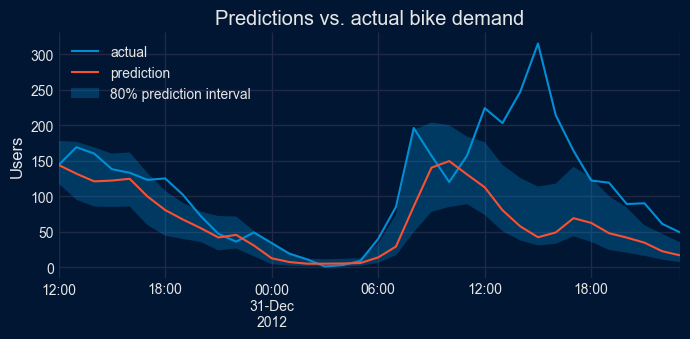

In [16]:
# Plot predictions vs. actual values for the held-out test period
# ==============================================================================
set_dark_theme()
preds = results_eval.predictions
fig, ax = plt.subplots(figsize=(7, 3.5))
data.set_index('date_time').loc[preds.index, 'users'].plot(ax=ax, label='actual')
preds['pred'].plot(ax=ax, label='prediction')
if {'lower_bound', 'upper_bound'}.issubset(preds.columns):
    ax.fill_between(
        preds.index, preds['lower_bound'], preds['upper_bound'],
        alpha=0.3, label='80% prediction interval'
    )
ax.set_title('Predictions vs. actual bike demand')
ax.set_ylabel('Users')
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# Ask the assistant to interpret the forecast results
# ==============================================================================
answer = assistant.ask(
    prompt  = "Explain the results of this forecast, including the metrics and predictions.",
    context = results_eval
)
answer.show_explanation()

/var/folders/wt/8tvn563d5v55nspfbydgqb9r0000gp/T/ipykernel_3200/3255811032.py:3: DataSentToLLMWarning: `send_data_to_llm=False` does not apply to `context`: the predicted values it carries are sent to the LLM, because a question about a result cannot be answered from summary statistics alone. Your input data is not sent: a result holds only the model's output, never the data it was fitted on. To keep predictions local, ask without `context`.
  answer = assistant.ask(


╭────────────────────────────────── Assistant Response ──────────────────────────────────╮
│                                                                                        │
│  The forecast for hourly bike rentals (users) was completed successfully using a       │
│  recursive machine learning forecaster with a LightGBM regressor over a 36-step        │
│  horizon. The model evaluated well, achieving a Mean Absolute Scaled Error (MASE) of   │
│  0.788656, which indicates that it outperforms the naive baseline. Point predictions   │
│  and 80 percent bootstrapping prediction intervals were generated for the entire       │
│  forecast period.                                                                      │
│                                                                                        │
│  Evaluation Metrics                                                                    │
│                                                                                        │
│  The model was evaluated using several metrics to measure its accuracy:                │
│                                                                                        │
│   • Mean Absolute Error (MAE): 50.780967                                               │
│   • Mean Squared Error (MSE): 6021.108727                                              │
│   • Mean Absolute Scaled Error (MASE): 0.788656 (a value below 1 indicates that the    │
│     model beats the naive baseline)                                                    │
│   • Mean Absolute Percentage Error (MAPE): 0.538557                                    │
│                                                                                        │
│  Predictions Summary                                                                   │
│                                                                                        │
│  The model produced predictions and an 80 percent bootstrapping prediction interval    │
│  for the 36-hour horizon. Based on the complete set of predictions, the summary        │
│  statistics are as follows:                                                            │
│                                                                                        │
│   • Predicted values (pred): The predicted values have a minimum of                    │
│     4.979050448742882, a maximum of 149.43208950163546, and a mean of                  │
│     63.59039395291701.                                                                 │
│   • Lower interval bound (lower_bound): The lower boundary ranges from a minimum of    │
│     0.880862087114048 to a maximum of 117.63971232660563, with a mean of               │
│     39.78729853264405.                                                                 │
│   • Upper interval bound (upper_bound): The upper boundary ranges from a minimum of    │
│     11.090115404550557 to a maximum of 203.8437034906251, with a mean of               │
│     102.98667295629922.                                                                │
│                                                                                        │
│  Because a portion of the hourly predictions is omitted from the output, specific      │
│  hourly progressions across the entire horizon are not detailed here. The per-column   │
│  summary statistics represent the complete forecast horizon.                           │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

### Prediction mode

In prediction mode, the model trains on the entire dataset and forecasts the next `steps` time points. Because the data includes exogenous variables (`holiday`, `weather`, `temp`), their future values must be supplied via the `exog` argument.

In [18]:
# Forecast the next 36 hours using the entire dataset (prediction mode)
# ==============================================================================
# Simulate future values of exogenous variables for the next 36 hours
exog = data[['holiday', 'weather', 'temp']].tail(36).copy()
exog.index = pd.date_range(
    start=pd.to_datetime(data['date_time'].max()) + pd.Timedelta(1, unit='h'),
    periods=36,
    freq='h'
)

results_pred = assistant.forecast(
    data        = data,
    steps       = 36,
    interval    = [0.1, 0.9],
    test_size   = None,        # Use the entire dataset (prediction mode)
    exog        = exog,        # Future values of exogenous variables
    profile     = profile,
    plan        = plan_refined
)

display(results_pred.predictions.head())

,pred,lower_bound,upper_bound
2013-01-01 00:00:00,20.809199,11.025294,32.736527
2013-01-01 01:00:00,11.205919,2.816770,22.254277
2013-01-01 02:00:00,6.691485,1.930920,13.281015
2013-01-01 03:00:00,5.646671,1.520065,9.863524
2013-01-01 04:00:00,6.665234,1.550711,13.256189


In [19]:
# Full results object
# ==============================================================================
results_pred

                          Dataset Profile                          
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property       ┃ Value                                          ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Format         │ single                                         │
├────────────────┼────────────────────────────────────────────────┤
│ Series         │ 1                                              │
├────────────────┼────────────────────────────────────────────────┤
│ Observations   │ 17544                                          │
├────────────────┼────────────────────────────────────────────────┤
│ Frequency      │ h                                              │
├────────────────┼────────────────────────────────────────────────┤
│ Target         │ users                                          │
├────────────────┼────────────────────────────────────────────────┤
│ Exog columns   │ holiday, weather, temp  (categorical: weather) │
├────────────────┼────────────────────────────────────────────────┤
│ Missing values │ None                                           │
└────────────────┴────────────────────────────────────────────────┘

                                    Recommendation                                     
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property              ┃ Value                                                       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type             │ single_series                                               │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Forecaster            │ ForecasterRecursive                                         │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Forecaster candidates │ ForecasterRecursive, ForecasterDirect, ForecasterFoundation │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Estimator             │ LGBMRegressor                                               │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Estimator candidates  │ LGBMRegressor, XGBRegressor, Ridge                          │
└───────────────────────┴─────────────────────────────────────────────────────────────┘

╭───────────────────────────────── Profile Explanation ──────────────────────────────────╮
│                                                                                        │
│  A single-series ML forecaster (ForecasterRecursive) is recommended. Data: 17544       │
│  observations, 'h' frequency. Alternative forecasters: ['ForecasterDirect',            │
│  'ForecasterFoundation']. Estimator: LGBMRegressor. A gradient boosting model is       │
│  preferred for a dataset of this size (17544 observations). Alternative estimators:    │
│  ['XGBRegressor', 'Ridge']. 3 exogenous variables (1 categorical) available as         │
│  predictors.                                                                           │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯
                                      Forecast Plan                                       
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property          ┃ Value                                                              ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type         │ single_series                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Forecaster        │ ForecasterRecursive                                             

### Code-only mode

Use `forecast_code()` when you want to preview or export the reproducible script without executing it. This is useful for code review, auditing the generated pipeline, or running the script in a separate environment.

In [20]:
# Generate the reproducible script without executing it
# ==============================================================================
code_result = assistant.forecast_code(
    data        = data,
    steps       = 36,
    test_size   = 36,
    profile     = profile,
    plan        = plan_refined
)
code_result.show_code()

### The ForecastResult object

Both `forecast()` modes return a `ForecastResult`, a lightweight container that bundles everything the assistant used and produced.

| Attribute | Type | Description |
|---|---|---|
| `predictions` | DataFrame | Forecasted values. When intervals are requested, the bound columns are included alongside the point predictions. |
| `metrics` | DataFrame or None | Evaluation metrics (`MAE`, `MSE`, `MASE`, `MAPE`), one row per series. `None` in prediction mode. |
| `code` | str | The exact standalone **skforecast** script that produced the forecast, ready to run on its own. |
| `profile` | `ForecastingProfile` | The data profile behind the forecast. |
| `plan` | `ForecastPlan` | The detailed configuration that was executed. |

## Backtesting

The backtesting branch uses the same `profile` and `plan` as the forecast branch but evaluates the model's historical performance through time series cross-validation. The key decision is how to configure the `TimeSeriesFold` object, which controls exactly how the historical data is partitioned into successive training and test windows.

skforecast-ai provides three distinct ways to define this validation strategy:

1. **Explicit instantiation (recommended)**: manually construct a `TimeSeriesFold` and pass it directly to `backtest()`. Use this when you already know your exact operational constraints.

2. **Deterministic `create_cv()`**: allow the assistant to derive a sensible `TimeSeriesFold` from the profile and plan using rule-based defaults. You can override individual parameters explicitly.

3. **LLM `create_cv()` (with a prompt)**: describe your deployment use case in natural language. The LLM translates your description into a fully-configured `TimeSeriesFold`, accompanied by an explanation you can audit.

### Define the backtesting strategy

#### Manual TimeSeriesFold

In [21]:
# Create your own TimeSeriesFold object
# ==============================================================================
end_train = '2012-08-31 23:59:00'
cv = TimeSeriesFold(
    steps              = 36,
    initial_train_size = end_train,
    refit              = False,
    verbose            = False
)
cv

TimeSeriesFold(
    initial_train_size    = 2012-08-31 23:59:00,
    steps                 = 36,
    fold_stride           = 36,
    window_size           = None,
    differentiation       = None,
    refit                 = False,
    fixed_train_size      = True,
    gap                   = 0,
    skip_folds            = None,
    allow_incomplete_fold = True,
    return_all_indexes    = False,
    verbose               = False,
)

#### Deterministic create_cv()

In [22]:
# Let the assistant derive a TimeSeriesFold with rule-based defaults
# ==============================================================================
cv_det = assistant.create_cv(
    profile            = profile,
    plan               = plan_refined,
    initial_train_size = end_train,
    refit              = False,
)

cv_det

╭───────────────────────────── Cross-Validation Explanation ─────────────────────────────╮
│                                                                                        │
│  Initial training up to 2012-08-31 23:59:00, expanding window, no refit, 36-step       │
│  horizon, 82 folds.                                                                    │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯
        Cross-Validation Configuration         
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter             ┃               Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ steps                 │                  36 │
├───────────────────────┼─────────────────────┤
│ initial_train_size    │ 2012-08-31 23:59:00 │
├───────────────────────┼─────────────────────┤
│ refit                 │               False │
├───────────────────────┼─────────────────────┤
│ fixed_train_size      │               False │
├───────────────────────┼─────────────────────┤
│ gap                   │                   0 │
├───────────────────────┼─────────────────────┤
│ fold_stride           │                  36 │
├───────────────────────┼─────────────────────┤
│ skip_folds            │                None │
├───────────────────────┼─────────────────────┤
│ allow_incomplete_fold │                True │
├───────────────────────┼─────────────────────┤
│ differentiation       │                None │
├───────────────────────┼─────────────────────┤
│ n_folds               │                  82 │
└───────────────────────┴─────────────────────┘
───────────────────────────────────── Generated code ─────────────────────────────────────
from skforecast.model_selection import TimeSeriesFold                                     
                                                                                          
# Time series cross-validation configuration                                              
cv = TimeSeriesFold(                                                                      
    steps              = 36,                                                              
    initial_train_size = '2012-08-31 23:59:00',                                           
    refit              = False,                                                           
)                                                                                         
                                                                                          

#### LLM create_cv() with a natural-language prompt

Rather than manually configuring `TimeSeriesFold` parameters, you can describe your backtesting strategy in natural language and let the assistant translate it into a rigorous cross-validation schema.

In [23]:
# Let the assistant create the TimeSeriesFold from a natural-language prompt
# ==============================================================================
prompt = (
    "I forecast bike demand 36 hours ahead. "
    "The model should be trained once on all data up to the end of August 2012, 23:59. "
    "Do not refit the model as the window rolls forward."
)
cv_llm = assistant.create_cv(
    profile = profile,
    plan    = plan_refined,
    prompt  = prompt
)

In [24]:
# Cross-validation strategy derived from the prompt
# ==============================================================================
cv_llm

╭───────────────────────────── Cross-Validation Explanation ─────────────────────────────╮
│                                                                                        │
│  The user requested training the model once up to the end of August 2012 (August 31,   │
│  2012 at 23:59, which maps to the 23:00 hourly timestamp). We set refit to False as    │
│  requested to avoid retraining the model as the evaluation window rolls forward. The   │
│  remaining portion of the 17,544 observations (~2,900 hours) is more than sufficient   │
│  to complete multiple folds of 36-step predictions. Initial training up to 2012-08-31  │
│  23:00:00, expanding window, no refit, 36-step horizon, 82 folds.                      │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯
        Cross-Validation Configuration         
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter             ┃               Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ steps                 │                  36 │
├───────────────────────┼─────────────────────┤
│ initial_train_size    │ 2012-08-31 23:00:00 │
├───────────────────────┼─────────────────────┤
│ refit                 │               False │
├───────────────────────┼─────────────────────┤
│ fixed_train_size      │               False │
├───────────────────────┼─────────────────────┤
│ gap                   │                   0 │
├───────────────────────┼─────────────────────┤
│ fold_stride           │                  36 │
├───────────────────────┼─────────────────────┤
│ skip_folds            │                None │
├───────────────────────┼─────────────────────┤
│ allow_incomplete_fold │                True │
├───────────────────────┼─────────────────────┤
│ differentiation       │                None │
├───────────────────────┼─────────────────────┤
│ n_folds               │                  82 │
└───────────────────────┴─────────────────────┘
───────────────────────────────────── Generated code ─────────────────────────────────────
from skforecast.model_selection import TimeSeriesFold                                     
                                                                                          
# Time series cross-validation configuration                                              
cv = TimeSeriesFold(                                                                      
    steps              = 36,                                                              
    initial_train_size = '2012-08-31 23:00:00',                                           
    refit              = False,                                                           
)                                                                                         
                                                                                          

In [25]:
# LLM reasoning behind the TimeSeriesFold configuration
# ==============================================================================
print(textwrap.fill(cv_llm.explanation, width=88))

The user requested training the model once up to the end of August 2012 (August 31, 2012
at 23:59, which maps to the 23:00 hourly timestamp). We set refit to False as requested
to avoid retraining the model as the evaluation window rolls forward. The remaining
portion of the 17,544 observations (~2,900 hours) is more than sufficient to complete
multiple folds of 36-step predictions. Initial training up to 2012-08-31 23:00:00,
expanding window, no refit, 36-step horizon, 82 folds.


Since the `prompt` correctly describes the intended use case, the `cv_llm` object returned by `create_cv()` is equivalent to the one we built manually (the same 82 folds; the timestamp is aligned to the hourly frequency). However, it was derived entirely from a natural-language description. The returned `CVResult` carries the splitter as `cv_llm.cv` and, as `cv_llm.explanation`, a description of the choices the assistant made, allowing you to verify that the resulting `TimeSeriesFold` matches your intended strategy before executing the backtest.

### Run the backtest

In [26]:
# Run backtesting, reusing the pre-computed profile and plan
# ==============================================================================
results_backtest = assistant.backtest(
    data        = data,
    cv          = cv,           # TimeSeriesFold object
    interval    = [0.1, 0.9],   # 80% prediction interval
    profile     = profile,      # Reuse the pre-computed profile
    plan        = plan_refined  # Reuse the refined plan
)

results_backtest.show_explanation()
display(results_backtest.metrics)
display(results_backtest.predictions.head())

  0%|          | 0/82 [00:00<?, ?it/s]

╭───────────────────────────────── Backtest Explanation ─────────────────────────────────╮
│                                                                                        │
│  Initial training up to 2012-08-31 23:59:00, fixed window, no refit, 36-step horizon,  │
│  82 folds. Results: mean_absolute_error: 50.2709, mean_squared_error: 7176.0230,       │
│  mean_absolute_scaled_error: 0.8199, mean_absolute_percentage_error: 0.5641.           │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

,mean_absolute_error,mean_squared_error,mean_absolute_scaled_error,mean_absolute_percentage_error
0,50.270879,7176.023044,0.819891,0.564145


,fold,pred,lower_bound,upper_bound
2012-09-01 00:00:00,0,131.971068,101.716617,155.867024
2012-09-01 01:00:00,0,103.769142,76.105128,134.466040
2012-09-01 02:00:00,0,68.989121,42.375183,101.041252
2012-09-01 03:00:00,0,37.476023,20.729892,71.145067
2012-09-01 04:00:00,0,15.675417,7.083384,38.050270


In [27]:
# Plot prediction intervals vs real value
# ==============================================================================
predictions = results_backtest.predictions
data_test = data.set_index("date_time").loc[predictions.index, :]

fig = go.Figure([
    go.Scatter(name='Prediction', x=predictions.index, y=predictions['pred'], mode='lines'),
    go.Scatter(
        name='Real value', x=data_test.index, y=data_test['users'], mode='lines',
    ),
    go.Scatter(
        name='Upper Bound', x=predictions.index, y=predictions['upper_bound'], mode='lines',
        marker=dict(color="#444"), line=dict(width=0), showlegend=False
    ),
    go.Scatter(
        name='Lower Bound', x=predictions.index, y=predictions['lower_bound'], marker=dict(color="#444"),
        line=dict(width=0), mode='lines', fillcolor='rgba(68, 68, 68, 0.3)', fill='tonexty', showlegend=False
    )
])
fig.update_layout(
    title="Real value vs predicted in test data",
    xaxis_title="Date time",
    yaxis_title="users",
    width=800,
    height=400,
    margin=dict(l=20, r=20, t=35, b=20),
    hovermode="x",
    legend=dict(orientation="h", yanchor="top", y=1.1, xanchor="left", x=0.001),
    # Initial zoom on x axis betwee 1 oct to 10 oct
    xaxis=dict(range=['2012-10-01', '2012-10-10'])
)
fig.show()

In [28]:
# Ask the assistant to interpret the backtesting results
# ==============================================================================
answer = assistant.ask(
    prompt = (
        "Explain the results of this backtesting, including the strategy, metrics, "
        "and predictions. Is the model good enough to deploy?"
    ),
    context = results_backtest
)
answer.show_explanation()

/var/folders/wt/8tvn563d5v55nspfbydgqb9r0000gp/T/ipykernel_3200/2899763076.py:3: DataSentToLLMWarning: `send_data_to_llm=False` does not apply to `context`: the predicted values it carries are sent to the LLM, because a question about a result cannot be answered from summary statistics alone. Your input data is not sent: a result holds only the model's output, never the data it was fitted on. To keep predictions local, ask without `context`.
  answer = assistant.ask(


╭────────────────────────────────── Assistant Response ──────────────────────────────────╮
│                                                                                        │
│  The backtesting results indicate that the model is suitable for deployment because    │
│  its performance beats the naive baseline. This is confirmed by a Mean Absolute        │
│  Scaled Error (MASE) of 0.819891, which is below the baseline threshold of 1. The      │
│  evaluation, spanning 82 folds with a 36-step horizon, demonstrates stable predictive  │
│  accuracy.                                                                             │
│                                                                                        │
│  Backtesting Strategy                                                                  │
│                                                                                        │
│  The evaluation utilized a ForecasterRecursive model with an LGBMRegressor estimator.  │
│                                                                                        │
│   • Lags: [1, 2, 3, 23, 24, 25, 167, 168, 169]                                         │
│   • Window features: rolling mean and standard deviation with a window size of 3,      │
│     rolling mean with a window size of 24, and rolling mean with a window size of      │
│     168.                                                                               │
│   • Calendar features: hour, day_of_week, weekend, and month.                          │
│   • Exogenous variables: holiday, weather (categorical), and temp.                     │
│   • Validation setup: Initial training up to 2012-08-31 23:59:00 with a fixed          │
│     training window and no retraining (refit=False). The evaluation used a 36-step     │
│     forecast horizon, a fold stride of 36, and a gap of 0, resulting in 82 folds.      │
│                                                                                        │
│  Evaluation Metrics                                                                    │
│                                                                                        │
│  The model was assessed across 2928 total predictions using the following metrics:     │
│                                                                                        │
│   • Mean Absolute Error (MAE): 50.270879                                               │
│   • Mean Squared Error (MSE): 7176.023044                                              │
│   • Mean Absolute Scaled Error (MASE): 0.819891                                        │
│   • Mean Absolute Percentage Error (MAPE): 0.564145                                    │
│                                                                                        │
│  Because the MASE is 0.819891, which is below 1, the model beats the naive baseline.   │
│                                                                                        │
│  Predictions and Interval Summary                                                      │
│                                                                                        │
│  The backtest generated 80% bootstrap prediction intervals (nominal interval of [0.1,  │
│  0.9]):                                                                                │
│                                                                                        │
│   • Predicted values (pred) range from a minimum of 2.5131520871871103 to a maximum    │
│     of 873.2489140002856, with a mean of 230.994037497287.                             │
│   • The lower bounds range from a minimum of -1.3295089358207925 to a maximum of       │
│     806.2311219899487, with a mean of 186.33827216419792.                              │
│   • The upper bounds range from a minimum of 6.7617176504861956 to a maximum of        │
│     903.4272071692654, with a mean of 281.58554814493584.                            

### Code-only mode

Use `backtest_code()` to generate the reproducible backtesting script without executing it.

In [29]:
# Generate the reproducible backtest script without executing it
# ==============================================================================
code_bt = assistant.backtest_code(
    data        = data,
    cv          = cv,
    profile     = profile,
    plan        = plan_refined
)
code_bt.show_code()

### The BacktestResult object

The `backtest()` method returns a `BacktestResult`, a lightweight container that bundles all the backtesting artifacts.

| Attribute | Type | Description |
|---|---|---|
| `predictions` | DataFrame | Full out-of-sample backtest predictions across all folds. |
| `metrics` | DataFrame | Backtesting metrics (`MAE`, `MSE`, `MASE`, `MAPE`), one row per series, computed across all folds. |
| `cv_config` | dict | Resolved `TimeSeriesFold` parameters for full traceability of the validation strategy. |
| `code` | str | The exact standalone **skforecast** script that reproduces the backtesting workflow. |
| `explanation` | str | Human-readable summary of the backtesting configuration and results. |
| `profile` | `ForecastingProfile` | The data profile behind the backtest. |
| `plan` | `ForecastPlan` | The detailed configuration that was executed. |

In [30]:
# Full results object
# ==============================================================================
results_backtest

╭───────────────────────────────── Backtest Explanation ─────────────────────────────────╮
│                                                                                        │
│  Initial training up to 2012-08-31 23:59:00, fixed window, no refit, 36-step horizon,  │
│  82 folds. Results: mean_absolute_error: 50.2709, mean_squared_error: 7176.0230,       │
│  mean_absolute_scaled_error: 0.8199, mean_absolute_percentage_error: 0.5641.           │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯
        Cross-Validation Configuration         
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter             ┃               Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ steps                 │                  36 │
├───────────────────────┼─────────────────────┤
│ initial_train_size    │ 2012-08-31 23:59:00 │
├───────────────────────┼─────────────────────┤
│ refit                 │               False │
├───────────────────────┼─────────────────────┤
│ fixed_train_size      │                True │
├───────────────────────┼─────────────────────┤
│ gap                   │                   0 │
├───────────────────────┼─────────────────────┤
│ fold_stride           │                  36 │
├───────────────────────┼─────────────────────┤
│ skip_folds            │                None │
├───────────────────────┼─────────────────────┤
│ allow_incomplete_fold │                True │
├───────────────────────┼─────────────────────┤
│ differentiation       │                None │
├───────────────────────┼─────────────────────┤
│ n_folds               │                  82 │
└───────────────────────┴─────────────────────┘
                                     Backtest Metrics                                     
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ mean_absolute_error ┃ mean_squared_error ┃ mean_absolute_scale… ┃ mean_absolute_perce… ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│             50.2709 │          7176.0230 │               0.8199 │               0.5641 │
└─────────────────────┴────────────────────┴──────────────────────┴──────────────────────┘
                    Backtest Predictions (2928 rows)                    
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Index               ┃    fold ┃     pred ┃ lower_bound ┃ upper_bound ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ 2012-09-01 00:00:00 │  0.0000 │ 131.9711 │    101.7166 │    155.8670 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-09-01 01:00:00 │  0.0000 │ 103.7691 │     76.1051 │    134.4660 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-09-01 02:00:00 │  0.0000 │  68.9891 │     42.3752 │    101.0413 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-09-01 03:00:00 │  0.0000 │  37.4760 │     20.7299 │     71.1451 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-09-01 04:00:00 │  0.0000 │  15.6754 │      7.0834 │     38.0503 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ ...                 │     ... │      ... │         ... │         ... │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-12-31 19:00:00 │ 81.0000 │  69.6902 │     35.3341 │    108.3139 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-12-31 20:00:00 │ 81.0000 │  60.2420 │     31.0732 │     92.8878 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-12-31 21:00:00 │ 81.0000 │  34.1779 │     15.8213 │     69.8248 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-12-31 22:00:00 │ 81.0000 │  24.1687 │     11.8094 │ 

## Comparing forecaster configurations

Choosing a forecasting model should not rely on intuition alone. Two configurations that look equally reasonable can perform very differently once evaluated on real temporal data. The most reliable approach is to test every candidate under **identical conditions** and compare their metrics.

The `compare()` method does exactly that. It receives a list of candidate configurations, backtests each one using the same `TimeSeriesFold` strategy, and returns a leaderboard ranked by the selected metric.

In the step-by-step path, the key argument is `profile`. Passing the profile computed at the beginning of this tutorial skips profiling entirely and guarantees that every candidate is evaluated against the **same** data profile. Note that `compare()` does not accept a `plan`: each candidate derives its own plan from the shared profile, which is precisely what makes the candidates differ.

Candidates can be provided in two ways:

+ **Automatic candidates (`candidates=None`)**: the assistant builds the comparison set from the `profile.forecaster_candidates` that belong to the same family as the recommended forecaster, so every row is scored on the same thing. For multi-series data, where a multi-series forecaster is never ranked against a multivariate one, the candidates are the estimators of the recommended forecaster instead. This is useful when exploring a new dataset without a predefined shortlist.

+ **Explicit candidates (recommended)**: pass a list of `(name, config)` tuples, where `name` labels the row in the leaderboard and `config` holds the same override keys understood by `plan()`: `'forecaster'`, `'estimator'`, `'estimator_kwargs'`, `'lags'` and `'window_features'`. This provides full control and makes the resulting table easier to interpret.

A failed candidate does not stop the comparison. Instead, a `CandidateFailedWarning` is issued, the row records the error and is placed last.

<div role="note"
    style="background: rgba(0,191,191,.08); border-left: 6px solid #00bfa5;
        border-radius: 6px; padding: 10px 12px; margin: 1em 0;">

<p style="display:flex; align-items:center; font-size:1rem; color:#00bfa5;
        margin:0 0 6px 0; font-weight:600;">
<span style="margin-right:6px; font-size:18px;">💡</span>
<strong style="margin-right:6px; font-size:18px;">Tip</strong>
</p>

<p>

All candidates use the same cross-validation strategy, ensuring a fair comparison. However, the results are only meaningful if the <code>cv</code> setup reflects the real use case where the model will be deployed. For example, if the production system retrains weekly, the backtest should also refit weekly. If the model is expected to forecast 24 hours ahead, the backtest should use a 24-hour horizon.

The evaluation window must also be representative. A period that is too short or dominated by unusual events (holidays, outages, or exceptional peaks) may favor a candidate that performs poorly over time. Define the validation setup carefully before comparing models so the final ranking is reliable.

</p>

</div>

### Automatic candidates

In [31]:
# Compare the forecaster candidates suggested by the profile
# ==============================================================================
results_compare = assistant.compare(
    data        = data,
    cv          = cv,       # Same TimeSeriesFold used in the backtest above
    candidates  = None,     # Candidates suggested by the assistant 
    profile     = profile   # Reuse the pre-computed profile
)

Comparing forecasters:   0%|          | 0/3 [00:00<?, ?it/s]

In [32]:
# Ranked leaderboard
# ==============================================================================
results_compare.results

,rank,name,forecaster,estimator,mean_absolute_error,mean_squared_error,mean_absolute_scaled_error,mean_absolute_percentage_error
0,1,ForecasterFoundation,ForecasterFoundation,Chronos-2,38.436160,4231.326474,0.597467,0.611349
1,2,ForecasterRecursive,ForecasterRecursive,LGBMRegressor,46.312218,5495.881638,0.749598,0.472735
2,3,ForecasterDirect,ForecasterDirect,LGBMRegressor,49.298312,5936.622526,0.797930,0.499413


In [33]:
# Deterministic summary of the comparison
# ==============================================================================
results_compare.show_explanation()

╭──────────────────────────────── Comparison Explanation ────────────────────────────────╮
│                                                                                        │
│  Compared 3 configurations, ranked ascending by mean_absolute_error. Shared            │
│  cross-validation strategy: Initial training up to 2012-08-31 23:59:00, fixed window,  │
│  no refit, 36-step horizon, 82 folds. Best: 'ForecasterFoundation'                     │
│  (ForecasterFoundation / Chronos-2) = 38.4362, 17.0% ahead of 'ForecasterRecursive'    │
│  (46.3122).                                                                            │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

### Explicit candidates

In practice, you will often already have a shortlist in mind: a fast baseline, a gradient boosting model, or a variant with a richer feature set. Passing explicit `(name, config)` tuples keeps the comparison focused and makes the resulting leaderboard easy to understand at a glance.

The `config` dictionary accepts the same overrides as `plan()`. Any omitted option falls back to the deterministic recommendation derived from the shared profile, so candidates can remain concise. For example, `{'forecaster': 'ForecasterDirect'}` changes only the forecaster while keeping the recommended estimator, lags, and features.

<div role="alert" style="background: rgba(255,145,0,.08); border-left: 6px solid #ff9100; border-radius: 6px; padding: 10px 12px; margin: 1em 0;">

<p style="display:flex; align-items:center; font-size:1rem; color:#ff9100; margin:0 0 6px 0; font-weight:600;">
    <span style="margin-right:6px; font-size:18px;">⚠️</span>
    <strong style="margin-right:6px; font-size:18px;">Computational cost</strong>
</p>

<p>
Each candidate is backtested independently across all folds, so runtime increases with both the number and complexity of the configurations. Comparing four candidates will take roughly four times as long as running one backtest.

Start with a small set of clearly different options, review the results, and refine from there. Testing many near-identical variants is costly and rarely useful.
</p>

</div>

In [34]:
# Compare an explicit shortlist of configurations
# ==============================================================================
candidates = [
    (
        "ridge_baseline",
        {
            "forecaster": "ForecasterRecursive",
            "estimator" : "Ridge",
            "lags"      : 24,
        }
    ),
    (
        "lgbm_daily_lags",
        {
            "forecaster": "ForecasterRecursive",
            "estimator" : "LGBMRegressor",
            "lags"      : 24,
        }
    ),
    (
        "refined_plan",
        {
            "forecaster"      : plan_refined.forecaster,
            "estimator"       : plan_refined.estimator,
            "lags"            : plan_refined.forecaster_kwargs.get("lags"),
            "window_features" : plan_refined.forecaster_kwargs.get("window_features"),
        }
    ),
    (
        "lgbm_direct",
        {
            "forecaster": "ForecasterDirect",
            "estimator" : "LGBMRegressor",
            "lags"      : 24,
        }
    ),
    (
        "foundation_model",
        {
            "forecaster": "ForecasterFoundation"
        }
    ),
]

results_compare = assistant.compare(
    data        = data,
    cv          = cv,
    candidates  = candidates,  # Specific candidates to compare
    metric      = ['mean_absolute_error', 'mean_absolute_scaled_error'],
    profile     = profile
)

Comparing forecasters:   0%|          | 0/5 [00:00<?, ?it/s]

The `refined_plan` candidate reuses the forecaster, estimator, lags and window features of the plan produced by `refine_plan()`. This is the recommended way to validate a refined plan: the leaderboard shows whether the extra domain knowledge actually improves the metrics compared to the deterministic baselines.

When several metrics are requested, all of them are shown as columns but only the **first** one drives the ranking.

In [35]:
# Ranked leaderboard, sorted by the first metric requested
# ==============================================================================
results_compare.results

,rank,name,forecaster,estimator,mean_absolute_error,mean_absolute_scaled_error
0,1,foundation_model,ForecasterFoundation,Chronos-2,38.436160,0.597467
1,2,lgbm_direct,ForecasterDirect,LGBMRegressor,50.224908,0.819189
2,3,refined_plan,ForecasterRecursive,LGBMRegressor,50.270879,0.819891
3,4,lgbm_daily_lags,ForecasterRecursive,LGBMRegressor,55.517689,0.905517
4,5,ridge_baseline,ForecasterRecursive,Ridge,93.145620,1.519244


### Inspect individual candidates

Because every candidate is a full `BacktestResult`, the details of any individual configuration remain available, including its metrics, its predictions and the standalone script that generated them.

In [36]:
# Inspect a specific candidate
# ==============================================================================
candidate = results_compare.candidates['foundation_model']

display(candidate.metrics)
display(candidate.predictions.head())
candidate.show_code()

,mean_absolute_error,mean_absolute_scaled_error
0,38.43616,0.597467


,level,fold,pred
2012-09-01 00:00:00,users,0,148.059464
2012-09-01 01:00:00,users,0,102.715004
2012-09-01 02:00:00,users,0,66.084427
2012-09-01 03:00:00,users,0,40.878662
2012-09-01 04:00:00,users,0,29.577866


### Reuse the winning configuration

The most useful result of a comparison is often not the leaderboard, but `best_candidate`. It is a complete `BacktestResult` carrying both the winning `profile` and `plan`, so it can be fed back into the step-by-step workflow without manually rebuilding the configuration.

In [37]:
# Winning configuration
# ==============================================================================
print(f"Best candidate: {results_compare.best_name}")
results_compare.best_candidate.plan

Best candidate: foundation_model


              Forecast Plan              
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property       ┃ Value                ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type      │ foundation           │
├────────────────┼──────────────────────┤
│ Forecaster     │ ForecasterFoundation │
├────────────────┼──────────────────────┤
│ Estimator      │ Chronos-2            │
├────────────────┼──────────────────────┤
│ Steps          │ 36                   │
├────────────────┼──────────────────────┤
│ Frequency      │ h                    │
├────────────────┼──────────────────────┤
│ Use exog       │ True                 │
├────────────────┼──────────────────────┤
│ Interval       │ None                 │
├────────────────┼──────────────────────┤
│ Primary metric │ mean_absolute_error  │
├────────────────┼──────────────────────┤
│ Preprocessing  │ 1 step               │
└────────────────┴──────────────────────┘

                                   Preprocessing Steps                                    
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Step                    ┃ Reason                                                       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ handle_categorical_exog │ Categorical exogenous variables detected: ['weather'].       │
│                         │ Chronos-2 consumes categorical covariates natively, so no    │
│                         │ encoding is needed.                                          │
└─────────────────────────┴──────────────────────────────────────────────────────────────┘

╭─────────────────────────────────── Plan Explanation ───────────────────────────────────╮
│                                                                                        │
│  Plan: ForecasterFoundation + Chronos-2. No lag or window features: the foundation     │
│  model forecasts directly from the raw context window. Exogenous variables included.   │
│  MAE is interpretable, robust to outliers, and works at any scale.                     │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

In [38]:
# Produce the final forecast with the winning configuration
# ==============================================================================
results_pred_best = assistant.forecast(
    data        = data,
    steps       = 36,
    interval    = [0.1, 0.9],
    test_size   = None,                                # Prediction mode
    exog        = exog,                                # Future values of exogenous variables
    profile     = results_compare.profile,             # Shared profile
    plan        = results_compare.best_candidate.plan  # Winning plan
)

results_pred_best.show_code()

### Explain mode (comparison)

Like any other result, a `ComparisonResult` can be passed to `ask()` as `context` to explain why the ranking looks the way it does. However, the LLM cannot change the outcome: all metrics and rankings are computed deterministically before it sees the result.

In [39]:
# Ask the assistant to interpret the comparison
# ==============================================================================
answer = assistant.ask(
    prompt = (
        "Explain the comparison results. Is the margin between the top candidates "
        "meaningful, or are they practically equivalent?"
    ),
    context = results_compare
)
answer.show_explanation()

/var/folders/wt/8tvn563d5v55nspfbydgqb9r0000gp/T/ipykernel_3200/2209842622.py:3: DataSentToLLMWarning: `send_data_to_llm=False` does not apply to `context`: the predicted values it carries are sent to the LLM, because a question about a result cannot be answered from summary statistics alone. Your input data is not sent: a result holds only the model's output, never the data it was fitted on. To keep predictions local, ask without `context`.
  answer = assistant.ask(


╭────────────────────────────────── Assistant Response ──────────────────────────────────╮
│                                                                                        │
│  The foundation model is the top-performing candidate, achieving a mean absolute       │
│  error of 38.436160. There is a meaningful margin of performance between this top      │
│  candidate and the rest of the field, with the foundation model finishing 23.5         │
│  percent ahead of the runner-up, lgbm_direct. However, the second-place lgbm_direct    │
│  and third-place refined_plan models are practically equivalent, separated by a        │
│  minimal margin in mean absolute error.                                                │
│                                                                                        │
│  Leaderboard Summary                                                                   │
│                                                                                        │
│   • foundation_model (ForecasterFoundation with Chronos-2): mean absolute error of     │
│     38.436160, mean absolute scaled error of 0.597467                                  │
│   • lgbm_direct (ForecasterDirect with LGBMRegressor): mean absolute error of          │
│     50.224908, mean absolute scaled error of 0.819189                                  │
│   • refined_plan (ForecasterRecursive with LGBMRegressor): mean absolute error of      │
│     50.270879, mean absolute scaled error of 0.819891                                  │
│   • lgbm_daily_lags (ForecasterRecursive with LGBMRegressor): mean absolute error of   │
│     55.517689, mean absolute scaled error of 0.905517                                  │
│   • ridge_baseline (ForecasterRecursive with Ridge): mean absolute error of            │
│     93.145620, mean absolute scaled error of 1.519244                                  │
│                                                                                        │
│  Margins and Metric Interpretation                                                     │
│                                                                                        │
│   • The top candidate, foundation_model, shows a clear advantage over all other        │
│     options. Its mean absolute error of 38.436160 places it 23.5 percent ahead of the  │
│     second-place model, lgbm_direct, which scored 50.224908.                           │
│   • The difference between the second-place lgbm_direct (50.224908) and the            │
│     third-place refined_plan (50.270879) is extremely small, meaning their predictive  │
│     performance is virtually identical.                                                │
│   • A mean absolute scaled error (MASE) below 1 indicates that a model outperforms     │
│     the naive baseline. Based on this metric, the top four candidates                  │
│     (foundation_model, lgbm_direct, refined_plan, and lgbm_daily_lags) all             │
│     successfully beat the naive baseline, while the ridge_baseline (MASE of 1.519244)  │
│     fails to do so.                                                                    │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

### The ComparisonResult object

The `compare()` method returns a `ComparisonResult`, which groups the shared setup, the ranked leaderboard, and the individual backtests in a single object.

| Attribute | Type | Description |
|---|---|---|
| `results` | DataFrame | Ranked leaderboard, one row per candidate, sorted best to worst. Columns: `rank`, `name`, `forecaster`, `estimator`, the metric columns, and `error` when at least one candidate failed. |
| `candidates` | dict | Mapping of candidate name to the full `BacktestResult` object. |
| `failures` | dict | Mapping of candidate name to a `CandidateFailure` describing why it failed. Empty when every candidate succeeds. |
| `ranking_metric` | str | Name of the metric used to sort `results`. |
| `cv_config` | dict | Resolved `TimeSeriesFold` parameters plus the resulting `n_folds`, applied identically to every candidate. |
| `profile` | `ForecastingProfile` | The shared data profile behind every candidate. |
| `explanation` | str | Deterministic, human-readable summary of the comparison. |
| `best_name` | str | Name of the top-ranked candidate. |
| `best_candidate` | `BacktestResult` | Top-ranked candidate as a complete `BacktestResult`. |

In [40]:
# Full results object
# ==============================================================================
results_compare

╭──────────────────────────────── Comparison Explanation ────────────────────────────────╮
│                                                                                        │
│  Compared 5 configurations, ranked ascending by mean_absolute_error. Shared            │
│  cross-validation strategy: Initial training up to 2012-08-31 23:59:00, fixed window,  │
│  no refit, 36-step horizon, 82 folds. Best: 'foundation_model' (ForecasterFoundation   │
│  / Chronos-2) = 38.4362, 23.5% ahead of 'lgbm_direct' (50.2249).                       │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯
                                    Comparison Results                                    
┏━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Index ┃ rank ┃         name ┃   forecaster ┃    estimator ┃ mean_absol… ┃ mean_absolu… ┃
┡━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ 0     │    1 │ foundation_… │ ForecasterF… │    Chronos-2 │     38.4362 │       0.5975 │
├───────┼──────┼──────────────┼──────────────┼──────────────┼─────────────┼──────────────┤
│ 1     │    2 │  lgbm_direct │ ForecasterD… │ LGBMRegress… │     50.2249 │       0.8192 │
├───────┼──────┼──────────────┼──────────────┼──────────────┼─────────────┼──────────────┤
│ 2     │    3 │ refined_plan │ ForecasterR… │ LGBMRegress… │     50.2709 │       0.8199 │
├───────┼──────┼──────────────┼──────────────┼──────────────┼─────────────┼──────────────┤
│ 3     │    4 │ lgbm_daily_… │ ForecasterR… │ LGBMRegress… │     55.5177 │       0.9055 │
├───────┼──────┼──────────────┼──────────────┼──────────────┼─────────────┼──────────────┤
│ 4     │    5 │ ridge_basel… │ ForecasterR… │        Ridge │     93.1456 │       1.5192 │
└───────┴──────┴──────────────┴──────────────┴──────────────┴─────────────┴──────────────┘

## Reproducible code

Every forecast or backtest workflow exposes the standalone skforecast script used to produce its results. This script is strictly deterministic, ensuring identical outputs for a given set of inputs and configurations. You can access the code at any time via the `show_code()` method.

## Free-form Q&A

The `ask()` method is not limited to interpreting workflow objects. Without any `context` attached, it works as a general forecasting knowledge assistant, useful for clarifying methodology, choosing between approaches, or understanding metric trade-offs.

In [41]:
# Ask a general forecasting question (no data or result required)
# ==============================================================================
answer = assistant.ask(
    prompt = (
        "For hourly demand with strong daily and weekly seasonality, when should "
        "I prefer a direct forecasting strategy over a recursive one?"
    )
)
answer.show_explanation()

╭────────────────────────────────── Assistant Response ──────────────────────────────────╮
│                                                                                        │
│  For hourly demand with strong daily and weekly seasonality, you should prefer a       │
│  direct forecasting strategy when your forecast horizon is long enough that recursive  │
│  error propagation becomes significant, or when the predictive relationships change    │
│  dramatically depending on how far ahead you are forecasting. For example, predicting  │
│  demand for the next hour relies heavily on immediate, transient trends (such as the   │
│  previous hour's demand), whereas predicting 24 hours ahead depends much more on       │
│  daily seasonality. By training independent models for each hour in your horizon, a    │
│  direct strategy avoids compounding recursive errors and allows each model to adapt    │
│  to its specific step.                                                                 │
│                                                                                        │
│  Why Choose a Direct Strategy for Seasonal Hourly Demand                               │
│                                                                                        │
│   • Prevention of Error Propagation: In a recursive strategy, predicting hour 24       │
│     requires feeding in 23 intermediate predictions, causing small errors to compound  │
│     rapidly over the horizon. A direct strategy trains a separate model for each       │
│     step, meaning predictions for hour 24 are made directly from observed historical   │
│     data.                                                                              │
│   • Horizon-Specific Specialization: The predictive relationships change across a      │
│     24-hour or 168-hour (weekly) seasonal cycle. A direct forecaster allows the model  │
│     designated for hour 24 to optimize specifically for daily patterns, while the      │
│     model for hour 168 optimizes specifically for weekly patterns.                     │
│   • Exogenous Variable Alignment: When incorporating hourly weather forecasts or       │
│     calendar events, a direct forecaster can map these future exogenous variables      │
│     directly to specific future target steps without intermediate feedback loops.      │
│                                                                                        │
│  Trade-offs to Consider                                                                │
│                                                                                        │
│   • Computational Overhead: Training a direct forecaster requires fitting $N$          │
│     independent models (where $N$ is your forecast horizon). For a full weekly         │
│     horizon of 168 hours, this means training 168 models, which is significantly       │
│     slower and requires more memory than the single model trained by a recursive       │
│     forecaster.                                                                        │
│   • Fixed Forecast Horizon: You must define the maximum number of steps at             │
│     initialization. A direct forecaster cannot predict beyond this predefined limit    │
│     at inference time, whereas a recursive forecaster can generate predictions for an  │
│     arbitrary number of future steps.                                                  │
│                                                                                        │
│  Recommended Next Steps                                                                │
│                                                                                        │
│   • Implement the Forecaster: Initialize your model using ForecasterDirect with an     │
│     estimator like LightGBM (LGBMRegressor) and specify your target hourly horizon     │
│     using the steps parameter.                                                       

## Summary

This tutorial covered the **step-by-step path** of `skforecast-ai`. Here is a recap of what each stage does and when to use it:

| Step | Method | When to use |
|---|---|---|
| 1. Profile | `profile()` | Always: produces the `ForecastingProfile` required by all downstream methods. |
| 2. Plan | `plan()` | Always: converts the profile into an executable configuration. |
| 3. Refine plan | `refine_plan()` | Optional: use when you want to override specific decisions (deterministic) or inject domain knowledge (LLM). Always evaluate the result. |
| 4a. Forecast | `forecast()` | When you want future predictions or a held-out evaluation in a single execution. |
| 4a. Code only | `forecast_code()` | When you want to preview or export the script without running it. |
| 4b. CV strategy | `create_cv()` | When you want the assistant to derive or translate a `TimeSeriesFold` for you. |
| 4b. Backtest | `backtest()` | When you want to evaluate the model over multiple historical folds. |
| 4b. Code only | `backtest_code()` | When you want to preview or export the backtesting script without running it. |
| 4c. Compare | `compare()` | When you want to rank several configurations under an identical cross-validation strategy and reuse the winner. |
| Any time | `ask()` | When you want an LLM explanation of any intermediate object or result, or a general forecasting Q&A. |

The key advantage of this path is that the `profile` and `plan` are built **once** and reused across both the forecast and backtest branches. This avoids redundant profiling and ensures that both branches use the same modeling configuration. The same profile can also be handed to `compare()`, so every candidate is ranked against the very same data profile.

For a faster alternative that runs the entire pipeline in a single call, see the [fast-path tutorial](./agentic-forecasting.html). For a comprehensive overview of backtesting mechanics, see the [skforecast backtesting user guide](https://skforecast.org/latest/user_guides/backtesting).